# **Web Scraping**

You will extract data from a website using webscraping and reqeust APIs process it using Pandas and Numpy libraries.


In [72]:
!pip install bs4
!pip install lxml
!pip install html5lib
!pip install requests

Import the required modules and functions


In [4]:
from bs4 import BeautifulSoup # this module helps in web scrapping.
import requests  # this module helps us to download a web page

<h2 id="BSO">Beautiful Soup Objects</h2>


Beautiful Soup is a Python library for pulling data out of HTML and XML files, we will focus on HTML files. This is accomplished by representing the HTML as a set of objects with methods used to parse the HTML.  We can navigate the HTML as a tree and/or filter out what we are looking for.

Consider the following HTML:


In [74]:
%%html

<!-- This is a comment in HTML -->
<!--This declares the document as an HTML5 document.
It tells the browser that this file should be rendered as an HTML document-->
<!DOCTYPE html>

<!-- This is the root element of the HTML document.
Everything inside this <html> tag is part of the webpage. -->
<html>

<!--The <head> section contains metadata and other information about the document.
The <title> tag specifies the title of the webpage, which appears in the browser tab.-->
<head>
<title>Page Title</title>
</head>

<!-- This marks the beginning of the visible content of the webpage.
Everything inside <body> will be displayed on the webpage. -->
<body>

<!-- <h3>: This is a heading of level 3 (smaller than <h1> but larger than <h4>).

<b id='boldest'>Tom Morthy</b>:
  <b>: This makes the text bold.
  id='boldest': This assigns an id attribute to the element, which can be used for CSS styling or JavaScript selection.
  <p>: This is a paragraph that displays the salary.
   -->
<h3><b id='boldest'>Tom Morthy</b></h3>
<p> Salary: $ 92,000,000 </p>
<h3> Rick Curry</h3>
<p> Salary: $85,000, 000 </p>
<h3> Kevin Thames </h3>
<p> Salary: $73,200, 000</p>

<!-- </body>: Closes the body section.
</html>: Closes the HTML document. -->
</body>
</html>

We can store it as a string in the variable HTML:


In [75]:
html="<!DOCTYPE html><html><head><title>Page Title</title></head><body><h3><b id='boldest'>Tom Morthy</b></h3><p> Salary: $ 92,000,000 </p><h3> Rick Curry</h3><p> Salary: $85,000, 000 </p><h3> Kevin Thames </h3><p> Salary: $73,200, 000</p></body></html>"

In [76]:
html

"<!DOCTYPE html><html><head><title>Page Title</title></head><body><h3><b id='boldest'>Tom Morthy</b></h3><p> Salary: $ 92,000,000 </p><h3> Rick Curry</h3><p> Salary: $85,000, 000 </p><h3> Kevin Thames </h3><p> Salary: $73,200, 000</p></body></html>"

To parse a document, pass it into the <code>BeautifulSoup</code> constructor, the <code>BeautifulSoup</code> object, which represents the document as a nested data structure:


In [77]:
soup = BeautifulSoup(html, "html.parser")

First, the document is converted to Unicode, (similar to ASCII),  and HTML entities are converted to Unicode characters. Beautiful Soup transforms a complex HTML document into a complex tree of Python objects. The <code>BeautifulSoup</code> object can create other types of objects. In this notebook, we will cover <code>BeautifulSoup</code> and <code>Tag</code> objects that for the purposes of this notebook are identical, and <code>NavigableString</code> objects.


In [78]:
soup

<!DOCTYPE html>
<html><head><title>Page Title</title></head><body><h3><b id="boldest">Tom Morthy</b></h3><p> Salary: $ 92,000,000 </p><h3> Rick Curry</h3><p> Salary: $85,000, 000 </p><h3> Kevin Thames </h3><p> Salary: $73,200, 000</p></body></html>

We can use the method <code>prettify()</code> to display the HTML in the nested structure:


In [79]:
print(soup.prettify())

<!DOCTYPE html>
<html>
 <head>
  <title>
   Page Title
  </title>
 </head>
 <body>
  <h3>
   <b id="boldest">
    Tom Morthy
   </b>
  </h3>
  <p>
   Salary: $ 92,000,000
  </p>
  <h3>
   Rick Curry
  </h3>
  <p>
   Salary: $85,000, 000
  </p>
  <h3>
   Kevin Thames
  </h3>
  <p>
   Salary: $73,200, 000
  </p>
 </body>
</html>



## Tags


Let's say we want the  title of the page and the name of the top paid player we can use the <code>Tag</code>. The <code>Tag</code> object corresponds to an HTML tag in the original document, for example, the tag title.


In [82]:
tag_object=soup.title
print("tag object:",tag_object)

tag object: <title>Page Title</title>


we can see the tag type <code>bs4.element.Tag</code>


In [83]:
print("tag object type:",type(tag_object))

tag object type: <class 'bs4.element.Tag'>


If there is more than one <code>Tag</code>  with the same name, the first element with that <code>Tag</code> name is called, this corresponds to the most paid player:


In [84]:
tag_object=soup.h3
tag_object

<h3><b id="boldest">Tom Morthy</b></h3>

In [85]:
tag_object=soup.h3
tag_object

<h3><b id="boldest">Tom Morthy</b></h3>

Enclosed in the bold attribute <code>b</code>, it helps to use the tree representation. We can navigate down the tree using the child attribute to get the name.


### Children, Parents, and Siblings


As stated above the <code>Tag</code> object is a tree of objects we can access the child of the tag or navigate down the branch as follows:


In [86]:
tag_child =tag_object.b
tag_child

<b id="boldest">Tom Morthy</b>

You can access the parent with the <code> parent</code>


In [88]:
parent_tag=tag_child.parent
parent_tag

<h3><b id="boldest">Tom Morthy</b></h3>

this is identical to


In [89]:
tag_object

<h3><b id="boldest">Tom Morthy</b></h3>

<code>tag_object</code> parent is the <code>body</code> element.


In [90]:
tag_object.parent

<body><h3><b id="boldest">Tom Morthy</b></h3><p> Salary: $ 92,000,000 </p><h3> Rick Curry</h3><p> Salary: $85,000, 000 </p><h3> Kevin Thames </h3><p> Salary: $73,200, 000</p></body>

<code>tag_object</code> sibling is the <code>paragraph</code> element


In [91]:
tag_object

<h3><b id="boldest">Tom Morthy</b></h3>

In [92]:
sibling_1=tag_object.next_sibling
sibling_1

<p> Salary: $ 92,000,000 </p>

`sibling_2` is the `header` element which is also a sibling of both `sibling_1` and `tag_object`


In [ ]:
sibling_2=sibling_1.next_sibling
sibling_2

<h3> Rick Curry</h3>

<h3 id="first_question">Exercise: <code>next_sibling</code></h3>


Using the object <code>sibling\_2</code> and the property <code>next_sibling</code> to find the salary of Rick Curry:


In [ ]:
sibling_3=sibling_2.next_sibling
sibling_3

<p> Salary: $85,000, 000 </p>

### HTML Attributes


If the tag has attributes, the tag <code>id="boldest"</code> has an attribute <code>id</code> whose value is <code>boldest</code>. You can access a tag’s attributes by treating the tag like a dictionary:


In [94]:
tag_child

<b id="boldest">Tom Morthy</b>

In [95]:
tag_child['id']

'boldest'

You can access that dictionary directly as <code>attrs</code>:


In [96]:
tag_child.attrs

{'id': 'boldest'}

### Navigable String


A string corresponds to a bit of text or content within a tag. Beautiful Soup uses the <code>NavigableString</code> class to contain this text. In our HTML we can obtain the name of the first player by extracting the sting of the <code>Tag</code> object <code>tag_child</code> as follows:


In [97]:
tag_child

<b id="boldest">Tom Morthy</b>

In [98]:
tag_string=tag_child.string
tag_string

'Tom Morthy'

we can verify the type is Navigable String


In [ ]:
type(tag_string)

bs4.element.NavigableString

A NavigableString is just like a Python string or Unicode string, to be more precise. The main difference is that it also supports some  <code>BeautifulSoup</code> features. We can covert it to string object in Python:


In [ ]:
unicode_string = str(tag_string)
unicode_string

'Tom Morthy'

<h2 id="filter">Filter</h2>


Filters allow you to find complex patterns, the simplest filter is a string. In this section we will pass a string to a different filter method and Beautiful Soup will perform a match against that exact string.  Consider the following HTML of rocket launchs:


In [99]:
%%html
<table>
  <tr>
    <td id='flight' >Flight No</td>
    <td>Launch site</td>
    <td>Payload mass</td>
   </tr>
  <tr>
    <td>1</td>
    <td><a href='https://en.wikipedia.org/wiki/Florida'>FloridaCity</a></td>
    <td>300 kg</td>
  </tr>
  <tr>
    <td>2</td>
    <td><a href='https://en.wikipedia.org/wiki/Texas'>Texas</a></td>
    <td>94 kg</td>
  </tr>
  <tr>
    <td>3</td>
    <td><a href='https://en.wikipedia.org/wiki/Florida'>Florida<a> </td>
    <td>80 kg</td>
  </tr>
</table>

Flight No,Launch site,Payload mass
1,FloridaCity,300 kg
2,Texas,94 kg
3,Florida,80 kg


# HTML Exercise: Creating a Simple Table
## Objective:
You will create a basic HTML table to display information about three students, including their Name, Age, and Favorite Subject.

## Instructions:
1. Create an HTML file named students_table.html.

2. Inside the <body> section, create a table with the following details:
  
*   Use the table tag.
*   Include a header row with column names: Name, Age, Favorite Subject.
*   Add three rows of student information.
*   Use the <th> tag for table headers and <td> for table data.

3. Save and open the file in a browser to check your work.

### Example Table:


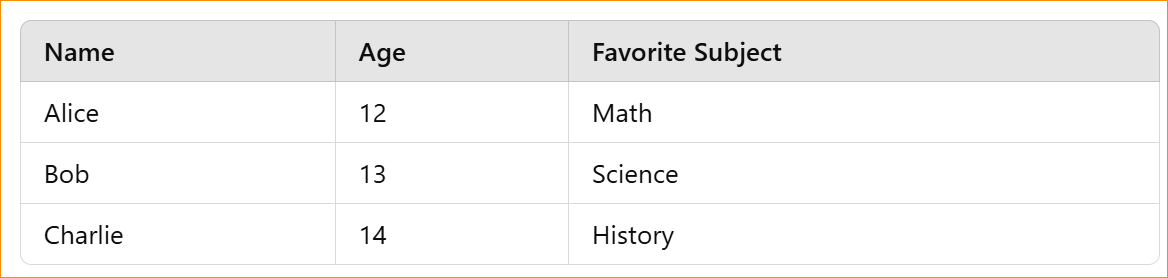

We can store it as a string in the variable <code>table</code>:


In [103]:
table="<table><tr><td id='flight'>Flight No</td><td>Launch site</td> <td>Payload mass</td></tr><tr> <td>1</td><td><a href='https://en.wikipedia.org/wiki/Florida'>Florida<a></td><td>300 kg</td></tr><tr><td>2</td><td><a href='https://en.wikipedia.org/wiki/Texas'>Texas</a></td><td>94 kg</td></tr><tr><td>3</td><td><a href='https://en.wikipedia.org/wiki/Florida'>Florida<a> </td><td>80 kg</td></tr></table>"

In [104]:
table_bs = BeautifulSoup(table, "html.parser")
table_bs

<table><tr><td id="flight">Flight No</td><td>Launch site</td> <td>Payload mass</td></tr><tr> <td>1</td><td><a href="https://en.wikipedia.org/wiki/Florida">Florida<a></a></a></td><td>300 kg</td></tr><tr><td>2</td><td><a href="https://en.wikipedia.org/wiki/Texas">Texas</a></td><td>94 kg</td></tr><tr><td>3</td><td><a href="https://en.wikipedia.org/wiki/Florida">Florida<a> </a></a></td><td>80 kg</td></tr></table>

In [105]:
print(table_bs.prettify())

<table>
 <tr>
  <td id="flight">
   Flight No
  </td>
  <td>
   Launch site
  </td>
  <td>
   Payload mass
  </td>
 </tr>
 <tr>
  <td>
   1
  </td>
  <td>
   <a href="https://en.wikipedia.org/wiki/Florida">
    Florida
    <a>
    </a>
   </a>
  </td>
  <td>
   300 kg
  </td>
 </tr>
 <tr>
  <td>
   2
  </td>
  <td>
   <a href="https://en.wikipedia.org/wiki/Texas">
    Texas
   </a>
  </td>
  <td>
   94 kg
  </td>
 </tr>
 <tr>
  <td>
   3
  </td>
  <td>
   <a href="https://en.wikipedia.org/wiki/Florida">
    Florida
    <a>
    </a>
   </a>
  </td>
  <td>
   80 kg
  </td>
 </tr>
</table>



## find All


The <code>find_all()</code> method looks through a tag’s descendants and retrieves all descendants that match your filters.

<p>
The Method signature for <code>find_all(name, attrs, recursive, string, limit, **kwargs)<c/ode>
</p>


### Name


When we set the <code>name</code> parameter to a tag name, the method will extract all the tags with that name and its children.


In [106]:
table_rows=table_bs.find_all('tr')
table_rows

[<tr><td id="flight">Flight No</td><td>Launch site</td> <td>Payload mass</td></tr>,
 <tr> <td>1</td><td><a href="https://en.wikipedia.org/wiki/Florida">Florida<a></a></a></td><td>300 kg</td></tr>,
 <tr><td>2</td><td><a href="https://en.wikipedia.org/wiki/Texas">Texas</a></td><td>94 kg</td></tr>,
 <tr><td>3</td><td><a href="https://en.wikipedia.org/wiki/Florida">Florida<a> </a></a></td><td>80 kg</td></tr>]

The result is a Python Iterable just like a list, each element is a <code>tag</code> object:


In [ ]:
first_row =table_rows[1]
first_row

<tr> <td>1</td><td><a href="https://en.wikipedia.org/wiki/Florida">Florida<a></a></a></td><td>300 kg</td></tr>

The type is <code>tag</code>


In [ ]:
print(type(first_row))

<class 'bs4.element.Tag'>


we can obtain the child


In [ ]:
first_row.td

<td>1</td>

If we iterate through the list, each element corresponds to a row in the table:


In [ ]:
for i,row in enumerate(table_rows):
    print("row",i,"is",row)


row 0 is <tr><td id="flight">Flight No</td><td>Launch site</td> <td>Payload mass</td></tr>
row 1 is <tr> <td>1</td><td><a href="https://en.wikipedia.org/wiki/Florida">Florida<a></a></a></td><td>300 kg</td></tr>
row 2 is <tr><td>2</td><td><a href="https://en.wikipedia.org/wiki/Texas">Texas</a></td><td>94 kg</td></tr>
row 3 is <tr><td>3</td><td><a href="https://en.wikipedia.org/wiki/Florida">Florida<a> </a></a></td><td>80 kg</td></tr>


As <code>row</code> is a <code>cell</code> object, we can apply the method <code>find_all</code> to it and extract table cells in the object <code>cells</code> using the tag <code>td</code>, this is all the children with the name <code>td</code>. The result is a list, each element corresponds to a cell and is a <code>Tag</code> object, we can iterate through this list as well. We can extract the content using the <code>string</code>  attribute.


In [ ]:
for i,row in enumerate(table_rows):
    print("row",i)
    cells=row.find_all('td')
    for j,cell in enumerate(cells):
        print('colunm',j,"cell",cell)

row 0
colunm 0 cell <td id="flight">Flight No</td>
colunm 1 cell <td>Launch site</td>
colunm 2 cell <td>Payload mass</td>
row 1
colunm 0 cell <td>1</td>
colunm 1 cell <td><a href="https://en.wikipedia.org/wiki/Florida">Florida<a></a></a></td>
colunm 2 cell <td>300 kg</td>
row 2
colunm 0 cell <td>2</td>
colunm 1 cell <td><a href="https://en.wikipedia.org/wiki/Texas">Texas</a></td>
colunm 2 cell <td>94 kg</td>
row 3
colunm 0 cell <td>3</td>
colunm 1 cell <td><a href="https://en.wikipedia.org/wiki/Florida">Florida<a> </a></a></td>
colunm 2 cell <td>80 kg</td>


If we use a list we can match against any item in that list.


In [ ]:
list_input=table_bs.find_all(name=["tr", "td"])
list_input

[<tr><td id="flight">Flight No</td><td>Launch site</td> <td>Payload mass</td></tr>,
 <td id="flight">Flight No</td>,
 <td>Launch site</td>,
 <td>Payload mass</td>,
 <tr> <td>1</td><td><a href="https://en.wikipedia.org/wiki/Florida">Florida<a></a></a></td><td>300 kg</td></tr>,
 <td>1</td>,
 <td><a href="https://en.wikipedia.org/wiki/Florida">Florida<a></a></a></td>,
 <td>300 kg</td>,
 <tr><td>2</td><td><a href="https://en.wikipedia.org/wiki/Texas">Texas</a></td><td>94 kg</td></tr>,
 <td>2</td>,
 <td><a href="https://en.wikipedia.org/wiki/Texas">Texas</a></td>,
 <td>94 kg</td>,
 <tr><td>3</td><td><a href="https://en.wikipedia.org/wiki/Florida">Florida<a> </a></a></td><td>80 kg</td></tr>,
 <td>3</td>,
 <td><a href="https://en.wikipedia.org/wiki/Florida">Florida<a> </a></a></td>,
 <td>80 kg</td>]

## Attributes


If the argument is not recognized it will be turned into a filter on the tag’s attributes. For example the <code>id</code>  argument, Beautiful Soup will filter against each tag’s <code>id</code> attribute. For example, the first <code>td</code> elements have a value of <code>id</code> of <code>flight</code>, therefore we can filter based on that <code>id</code> value.


In [ ]:
table_bs.find_all(id="flight")

[<td id="flight">Flight No</td>]

We can find all the elements that have links to the Florida Wikipedia page:


In [ ]:
list_input=table_bs.find_all(href="https://en.wikipedia.org/wiki/Florida")
list_input

[<a href="https://en.wikipedia.org/wiki/Florida">Florida<a></a></a>,
 <a href="https://en.wikipedia.org/wiki/Florida">Florida<a> </a></a>]

If we set the  <code>href</code> attribute to True, regardless of what the value is, the code finds all tags with <code>href</code> value:


In [ ]:
table_bs.find_all(href=True)

[<a href="https://en.wikipedia.org/wiki/Florida">Florida<a></a></a>,
 <a href="https://en.wikipedia.org/wiki/Texas">Texas</a>,
 <a href="https://en.wikipedia.org/wiki/Florida">Florida<a> </a></a>]

<h3 id="exer_type">Exercise: <code>find_all</code></h3>


Using the logic above, find all the elements without <code>href</code> value


In [ ]:
table_bs.find_all(href=False)

[<table><tr><td id="flight">Flight No</td><td>Launch site</td> <td>Payload mass</td></tr><tr> <td>1</td><td><a href="https://en.wikipedia.org/wiki/Florida">Florida<a></a></a></td><td>300 kg</td></tr><tr><td>2</td><td><a href="https://en.wikipedia.org/wiki/Texas">Texas</a></td><td>94 kg</td></tr><tr><td>3</td><td><a href="https://en.wikipedia.org/wiki/Florida">Florida<a> </a></a></td><td>80 kg</td></tr></table>,
 <tr><td id="flight">Flight No</td><td>Launch site</td> <td>Payload mass</td></tr>,
 <td id="flight">Flight No</td>,
 <td>Launch site</td>,
 <td>Payload mass</td>,
 <tr> <td>1</td><td><a href="https://en.wikipedia.org/wiki/Florida">Florida<a></a></a></td><td>300 kg</td></tr>,
 <td>1</td>,
 <td><a href="https://en.wikipedia.org/wiki/Florida">Florida<a></a></a></td>,
 <a></a>,
 <td>300 kg</td>,
 <tr><td>2</td><td><a href="https://en.wikipedia.org/wiki/Texas">Texas</a></td><td>94 kg</td></tr>,
 <td>2</td>,
 <td><a href="https://en.wikipedia.org/wiki/Texas">Texas</a></td>,
 <td>94 k

<details><summary>Click here for the solution</summary>

```
table_bs.find_all(href=False)

```

</details>


Using the soup object <code>soup</code>, find the element with the <code>id</code> attribute content set to <code>"boldest"</code>.


In [ ]:
soup.find_all(id="boldest")

[<b id="boldest">Tom Morthy</b>]

<details><summary>Click here for the solution</summary>

```
soup.find_all(id="boldest")

```

</details>


### string


With string you can search for strings instead of tags, where we find all the elments with Florida:


In [ ]:
table_bs.find_all(string="Florida")

['Florida', 'Florida']

## find


The <code>find_all()</code> method scans the entire document looking for results, it’s if you are looking for one element you can use the <code>find()</code> method to find the first element in the document. Consider the following two table:


In [107]:
%%html
<h3>Rocket Launch </h3>

<p>
<table class='rocket'>
  <tr>
    <td>Flight No</td>
    <td>Launch site</td>
    <td>Payload mass</td>
  </tr>
  <tr>
    <td>1</td>
    <td>Florida</td>
    <td>300 kg</td>
  </tr>
  <tr>
    <td>2</td>
    <td>Texas</td>
    <td>94 kg</td>
  </tr>
  <tr>
    <td>3</td>
    <td>Florida </td>
    <td>80 kg</td>
  </tr>
</table>
</p>
<p>

<h3>Pizza Party  </h3>


<table class='pizza'>
  <tr>
    <td>Pizza Place</td>
    <td>Orders</td>
    <td>Slices </td>
   </tr>
  <tr>
    <td>Domino's Pizza</td>
    <td>10</td>
    <td>100</td>
  </tr>
  <tr>
    <td>Little Caesars</td>
    <td>12</td>
    <td >144 </td>
  </tr>
  <tr>
    <td>Papa John's </td>
    <td>15 </td>
    <td>165</td>
  </tr>


Flight No,Launch site,Payload mass
1,Florida,300 kg
2,Texas,94 kg
3,Florida,80 kg
Pizza Place,Orders,Slices
Domino's Pizza,10,100
Little Caesars,12,144
Papa John's,15,165


We store the HTML as a Python string and assign <code>two_tables</code>:


In [108]:
two_tables="<h3>Rocket Launch </h3><p><table class='rocket'><tr><td>Flight No</td><td>Launch site</td> <td>Payload mass</td></tr><tr><td>1</td><td>Florida</td><td>300 kg</td></tr><tr><td>2</td><td>Texas</td><td>94 kg</td></tr><tr><td>3</td><td>Florida </td><td>80 kg</td></tr></table></p><p><h3>Pizza Party  </h3><table class='pizza'><tr><td>Pizza Place</td><td>Orders</td> <td>Slices </td></tr><tr><td>Domino's Pizza</td><td>10</td><td>100</td></tr><tr><td>Little Caesars</td><td>12</td><td >144 </td></tr><tr><td>Papa John's </td><td>15 </td><td>165</td></tr>"

We create a <code>BeautifulSoup</code> object  <code>two_tables_bs</code>


In [109]:
two_tables_bs= BeautifulSoup(two_tables, 'html.parser')

In [110]:
two_tables_bs

<h3>Rocket Launch </h3><p><table class="rocket"><tr><td>Flight No</td><td>Launch site</td> <td>Payload mass</td></tr><tr><td>1</td><td>Florida</td><td>300 kg</td></tr><tr><td>2</td><td>Texas</td><td>94 kg</td></tr><tr><td>3</td><td>Florida </td><td>80 kg</td></tr></table></p><p><h3>Pizza Party  </h3><table class="pizza"><tr><td>Pizza Place</td><td>Orders</td> <td>Slices </td></tr><tr><td>Domino's Pizza</td><td>10</td><td>100</td></tr><tr><td>Little Caesars</td><td>12</td><td>144 </td></tr><tr><td>Papa John's </td><td>15 </td><td>165</td></tr></table></p>

In [112]:
print(two_tables_bs.prettify())

<h3>
 Rocket Launch
</h3>
<p>
 <table class="rocket">
  <tr>
   <td>
    Flight No
   </td>
   <td>
    Launch site
   </td>
   <td>
    Payload mass
   </td>
  </tr>
  <tr>
   <td>
    1
   </td>
   <td>
    Florida
   </td>
   <td>
    300 kg
   </td>
  </tr>
  <tr>
   <td>
    2
   </td>
   <td>
    Texas
   </td>
   <td>
    94 kg
   </td>
  </tr>
  <tr>
   <td>
    3
   </td>
   <td>
    Florida
   </td>
   <td>
    80 kg
   </td>
  </tr>
 </table>
</p>
<p>
 <h3>
  Pizza Party
 </h3>
 <table class="pizza">
  <tr>
   <td>
    Pizza Place
   </td>
   <td>
    Orders
   </td>
   <td>
    Slices
   </td>
  </tr>
  <tr>
   <td>
    Domino's Pizza
   </td>
   <td>
    10
   </td>
   <td>
    100
   </td>
  </tr>
  <tr>
   <td>
    Little Caesars
   </td>
   <td>
    12
   </td>
   <td>
    144
   </td>
  </tr>
  <tr>
   <td>
    Papa John's
   </td>
   <td>
    15
   </td>
   <td>
    165
   </td>
  </tr>
 </table>
</p>



We can find the first table using the tag name table


In [113]:
two_tables_bs.find("table")

<table class="rocket"><tr><td>Flight No</td><td>Launch site</td> <td>Payload mass</td></tr><tr><td>1</td><td>Florida</td><td>300 kg</td></tr><tr><td>2</td><td>Texas</td><td>94 kg</td></tr><tr><td>3</td><td>Florida </td><td>80 kg</td></tr></table>

We can filter on the class attribute to find the second table, but because class is a keyword in Python, we add an underscore.


In [114]:
two_tables_bs.find("table",class_='pizza')

<table class="pizza"><tr><td>Pizza Place</td><td>Orders</td> <td>Slices </td></tr><tr><td>Domino's Pizza</td><td>10</td><td>100</td></tr><tr><td>Little Caesars</td><td>12</td><td>144 </td></tr><tr><td>Papa John's </td><td>15 </td><td>165</td></tr></table>

<h2 id="DSCW">Downloading And Scraping The Contents Of A Web Page</h2>


We Download the contents of the web page:


In [ ]:
url = "http://www.ibm.com"

We use <code>get</code> to download the contents of the webpage in text format and store in a variable called <code>data</code>:


In [ ]:
data  = requests.get(url).text

In [ ]:
data

'\n<!DOCTYPE HTML>\n<html lang="en">\n<head>\r\n    \r\n    \r\n    \r\n    \r\n    \r\n    \r\n    \r\n      \r\n    \r\n    \r\n    \r\n    \r\n    <meta charset="UTF-8"/>\r\n    <meta name="languageCode" content="en"/>\r\n    <meta name="countryCode" content="us"/>\r\n    <meta name="searchTitle" content="IBM - United States"/>\r\n    <meta name="focusArea" content="Cross IBM - All"/>\r\n    <title>IBM - United States</title>\r\n    <script defer="defer" type="text/javascript" src="https://rum.hlx.page/.rum/@adobe/helix-rum-js@%5E2/dist/rum-standalone.js" data-routing="program=131558,environment=1281329,tier=publish"></script>\n<link rel="icon" href="/content/dam/adobe-cms/default-images/favicon.svg"/>\r\n    \r\n    <meta name="description" content="For more than a century, IBM has been a global technology innovator, leading advances in AI, automation and hybrid cloud solutions that help businesses grow."/>\r\n    <meta name="template" content="full-width-layout"/>\r\n    <meta nam

We create a <code>BeautifulSoup</code> object using the <code>BeautifulSoup</code> constructor


In [115]:
soup = BeautifulSoup(data,"html.parser")  # create a soup object using the variable 'data'

In [ ]:
#soup

Scrape all links


In [ ]:
for link in soup.find_all('a',href=True):  # in html anchor/link is represented by the tag <a>

    print(link.get('href'))


https://www.ibm.com/granite?lnk=hpad1us
https://developer.ibm.com/technologies/artificial-intelligence?lnk=hpad2us
https://www.ibm.com/products/watsonx-code-assistant?lnk=hpad3us
https://www.ibm.com/watsonx/developer/?lnk=hpad4us
https://www.ibm.com/thought-leadership/institute-business-value/report/ceo-generative-ai?lnk=hpab1us
https://www.ibm.com/think/reports/ai-in-action?lnk=hpab2us
https://www.ibm.com/impact/ai-ethics?lnk=hpab3us
https://www.ibm.com/account/reg/signup?formid=news-urx-52954&lnk=hpab4us
https://www.ibm.com/artificial-intelligence?lnk=hpfp1us
https://www.ibm.com/hybrid-cloud?lnk=hpfp2us
https://www.ibm.com/consulting?lnk=hpfp3us
https://www.ibm.com/case-studies/water-corporation
https://www.ibm.com/case-studies/ibm-software-team


## Scrape  all images  Tags


In [116]:
for link in soup.find_all('img'):# in html image is represented by the tag <img>
    print(link)
    print(link.get('src'))

<img alt="" aria-hidden="true" class="mw-logo-icon" height="50" src="/static/images/icons/wikipedia.png" width="50"/>
/static/images/icons/wikipedia.png
<img alt="Wikipedia" class="mw-logo-wordmark" src="/static/images/mobile/copyright/wikipedia-wordmark-en.svg" style="width: 7.5em; height: 1.125em;"/>
/static/images/mobile/copyright/wikipedia-wordmark-en.svg
<img alt="The Free Encyclopedia" class="mw-logo-tagline" height="13" src="/static/images/mobile/copyright/wikipedia-tagline-en.svg" style="width: 7.3125em; height: 0.8125em;" width="117"/>
/static/images/mobile/copyright/wikipedia-tagline-en.svg
<img alt="Page semi-protected" class="mw-file-element" data-file-height="512" data-file-width="512" decoding="async" height="20" src="//upload.wikimedia.org/wikipedia/en/thumb/1/1b/Semi-protection-shackle.svg/20px-Semi-protection-shackle.svg.png" srcset="//upload.wikimedia.org/wikipedia/en/thumb/1/1b/Semi-protection-shackle.svg/30px-Semi-protection-shackle.svg.png 1.5x, //upload.wikimedia.

## Scrape data from HTML tables into a DataFrame using BeautifulSoup and Pandas


In [1]:
import pandas as pd

In [2]:
#The below url contains html tables with data about world population.
url = "https://en.wikipedia.org/wiki/World_population"

Before proceeding to scrape a web site, you need to examine the contents, and the way data is organized on the website. Open the above url in your browser and check the tables on the webpage.


In [5]:
# get the contents of the webpage in text format and store in a variable called data
data  = requests.get(url).text

In [6]:
soup = BeautifulSoup(data,"html.parser")

In [7]:
#find all html tables in the web page
tables = soup.find_all('table')
# tables# in html table is represented by the tag <table>

In [8]:
# we can see how many tables were found by checking the length of the tables list
len(tables)

27

Assume that we are looking for the `10 most densly populated countries` table, we can look through the tables list and find the right one we are look for based on the data in each table or we can search for the table name if it is in the table but this option might not always work.


In [9]:
tables[6]

<table class="wikitable sortable" style="text-align:right">
<caption>10 most densely populated countries <small>(with population above 5 million)</small><sup class="reference" id="cite_ref-:10_103-0"><a href="#cite_note-:10-103"><span class="cite-bracket">[</span>98<span class="cite-bracket">]</span></a></sup>
</caption>
<tbody><tr>
<th scope="col">Rank
</th>
<th scope="col">Country
</th>
<th scope="col">Population
</th>
<th scope="col">Area<br/><small>(km<sup>2</sup>)</small>
</th>
<th scope="col">Density<br/><small>(pop/km<sup>2</sup>)</small>
</th></tr>
<tr>
<td>1</td>
<td align="left"><span class="flagicon"><span class="mw-image-border" typeof="mw:File"><span><img alt="" class="mw-file-element" data-file-height="600" data-file-width="900" decoding="async" height="15" src="//upload.wikimedia.org/wikipedia/commons/thumb/4/48/Flag_of_Singapore.svg/23px-Flag_of_Singapore.svg.png" srcset="//upload.wikimedia.org/wikipedia/commons/thumb/4/48/Flag_of_Singapore.svg/35px-Flag_of_Singapore.sv

In [10]:
for index,table in enumerate(tables):
    if ("10 most densely populated countries" in str(table)):
        table_index = index
print(table_index)

6


See if you can locate the table name of the table, `10 most densly populated countries`, below.


In [11]:
print(tables[table_index].prettify())

<table class="wikitable sortable" style="text-align:right">
 <caption>
  10 most densely populated countries
  <small>
   (with population above 5 million)
  </small>
  <sup class="reference" id="cite_ref-:10_103-0">
   <a href="#cite_note-:10-103">
    <span class="cite-bracket">
     [
    </span>
    98
    <span class="cite-bracket">
     ]
    </span>
   </a>
  </sup>
 </caption>
 <tbody>
  <tr>
   <th scope="col">
    Rank
   </th>
   <th scope="col">
    Country
   </th>
   <th scope="col">
    Population
   </th>
   <th scope="col">
    Area
    <br/>
    <small>
     (km
     <sup>
      2
     </sup>
     )
    </small>
   </th>
   <th scope="col">
    Density
    <br/>
    <small>
     (pop/km
     <sup>
      2
     </sup>
     )
    </small>
   </th>
  </tr>
  <tr>
   <td>
    1
   </td>
   <td align="left">
    <span class="flagicon">
     <span class="mw-image-border" typeof="mw:File">
      <span>
       <img alt="" class="mw-file-element" data-file-height="600" data-fi

In [12]:
population_data = pd.DataFrame(columns=["Rank", "Country", "Population", "Area", "Density"])

for row in tables[table_index].tbody.find_all("tr"):
    col = row.find_all("td")
    if (col != []):
        rank = col[0].text
        country = col[1].text
        population = col[2].text.strip()
        area = col[3].text.strip()
        density = col[4].text.strip()
        # Use pd.concat instead of append
        population_data = pd.concat([population_data, pd.DataFrame({"Rank": [rank], "Country": [country], "Population": [population], "Area": [area], "Density": [density]})], ignore_index=True)

population_data

,Rank,Country,Population,Area,Density
0,1,Singapore,"5,921,231",719,"8,235"
1,2,Bangladesh,"165,650,475","148,460","1,116"
2,3,\n Palestine[note 3][99]\n\n,"5,223,000","6,025",867
3,4,Taiwan[note 4],"23,580,712","35,980",655
4,5,South Korea,"51,844,834","99,720",520
5,6,Lebanon,"5,296,814","10,400",509
6,7,Rwanda,"13,173,730","26,338",500
7,8,Burundi,"12,696,478","27,830",456
8,9,Israel,"9,402,617","21,937",429
9,10,India,"1,389,637,446","3,287,263",423


## Scrape data from HTML tables into a DataFrame using read_html


We can also use the `read_html` function to directly get DataFrames from a `url`.


In [13]:
dataframe_list = pd.read_html(url, flavor='bs4')

We can see there are 25 DataFrames just like when we used `find_all` on the `soup` object.


In [14]:
dataframe_list

[      Population         1     2     3     4     5     6     7     8     9  \
 0           Year      1804  1927  1960  1974  1987  1999  2011  2022  2037   
 1  Years elapsed  200,000+   123    33    14    13    12    12    11    15   
 
      10  
 0  2057  
 1    20  ,
                                Region  2022 (percent)  2030 (percent)  \
 0                  Sub-Saharan Africa  1,152 (14.51%)  1,401 (16.46%)   
 1    Northern Africa and Western Asia     549 (6.91%)     617 (7.25%)   
 2      Central Asia and Southern Asia  2,075 (26.13%)  2,248 (26.41%)   
 3  Eastern Asia and Southeastern Asia  2,342 (29.49%)  2,372 (27.87%)   
 4         Europe and Northern America  1,120 (14.10%)  1,129 (13.26%)   
 5     Latin America and the Caribbean     658 (8.29%)     695 (8.17%)   
 6           Australia and New Zealand      31 (0.39%)      34 (0.40%)   
 7                             Oceania      14 (0.18%)      15 (0.18%)   
 8                               World            7942       

In [15]:
len(dataframe_list)

27

Finally we can pick the DataFrame we need out of the list.


In [16]:
dataframe_list[6]

,Rank,Country,Population,Area (km2),Density (pop/km2)
0,1,Singapore,5921231,719,8235
1,2,Bangladesh,165650475,148460,1116
2,3,Palestine[note 3][99],5223000,6025,867
3,4,Taiwan[note 4],23580712,35980,655
4,5,South Korea,51844834,99720,520
5,6,Lebanon,5296814,10400,509
6,7,Rwanda,13173730,26338,500
7,8,Burundi,12696478,27830,456
8,9,Israel,9402617,21937,429
9,10,India,1389637446,3287263,423


We can also use the `match` parameter to select the specific table we want. If the table contains a string matching the text it will be read.


In [17]:
tabel_df = pd.read_html(url, match="10 most densely populated countries", flavor='bs4')

In [18]:
type(tabel_df)

list

In [20]:
tabel_df

[   Rank                Country  Population  Area (km2)  Density (pop/km2)
 0     1              Singapore     5921231         719               8235
 1     2             Bangladesh   165650475      148460               1116
 2     3  Palestine[note 3][99]     5223000        6025                867
 3     4         Taiwan[note 4]    23580712       35980                655
 4     5            South Korea    51844834       99720                520
 5     6                Lebanon     5296814       10400                509
 6     7                 Rwanda    13173730       26338                500
 7     8                Burundi    12696478       27830                456
 8     9                 Israel     9402617       21937                429
 9    10                  India  1389637446     3287263                423]

In [22]:
tabel_df[0]

,Rank,Country,Population,Area (km2),Density (pop/km2)
0,1,Singapore,5921231,719,8235
1,2,Bangladesh,165650475,148460,1116
2,3,Palestine[note 3][99],5223000,6025,867
3,4,Taiwan[note 4],23580712,35980,655
4,5,South Korea,51844834,99720,520
5,6,Lebanon,5296814,10400,509
6,7,Rwanda,13173730,26338,500
7,8,Burundi,12696478,27830,456
8,9,Israel,9402617,21937,429
9,10,India,1389637446,3287263,423


In [ ]:
pd.read_html(url, match="10 most densely populated countries", flavor='bs4')[0]

,Rank,Country,Population,Area (km2),Density (pop/km2)
0,1,Singapore,5921231,719,8235
1,2,Bangladesh,165650475,148460,1116
2,3,Palestine[note 3][99],5223000,6025,867
3,4,Taiwan[note 4],23580712,35980,655
4,5,South Korea,51844834,99720,520
5,6,Lebanon,5296814,10400,509
6,7,Rwanda,13173730,26338,500
7,8,Burundi,12696478,27830,456
8,9,Israel,9402617,21937,429
9,10,India,1389637446,3287263,423


# Exercise for you

## Project Scenario:
An international firm that is looking to expand its business in different countries across the world has recruited you. You have been hired as a junior Data Engineer and are tasked with creating a script that can extract the list of the top 10 largest economies of the world in descending order of their GDPs in Billion USD (rounded to 2 decimal places), as logged by the International Monetary Fund (IMF).

The required data seems to be available on the URL mentioned below:

URL: https://en.wikipedia.org/wiki/List_of_countries_by_GDP_(nominal)


## Objectives

After completing this lab you will be able to:

 - Use Webscraping to extract required information from a website.
 - Use Pandas to load and process the tabular data as a dataframe.
 - Use Numpy to manipulate the information contatined in the dataframe.
 - Load the updated dataframe to CSV file.

### Exercise 1
Extract the required GDP data from the given URL using Web Scraping.

URL=https://en.wikipedia.org/wiki/List_of_countries_by_GDP_(nominal)


You can use Pandas library to extract the required table directly as a DataFrame.


In [26]:
URL = "https://en.wikipedia.org/wiki/List_of_countries_by_GDP_(nominal)"
new_table = pd.read_html(URL, match="GDP forecast or estimate", flavor='bs4')[0]
new_table

Country/Territory IMF[1][13]            World Bank[14]             \
    Country/Territory   Forecast       Year       Estimate       Year   
0               World  115494312       2025      105435540       2023   
1       United States   30337162       2025       27360935       2023   
2               China   19534894  [n 1]2025       17794782  [n 3]2023   
3             Germany    4921563       2025        4456081       2023   
4               Japan    4389326       2025        4212945       2023   
..                ...        ...        ...            ...        ...   
205          Kiribati        311       2024            279       2023   
206             Palau        308       2024            263       2023   
207  Marshall Islands        305       2024            284       2023   
208             Nauru        161       2024            154       2023   
209            Tuvalu         66       2024             62       2023   

    United Nations[15]             
              Estimate       Year  
0            100834796       2022  
1             25744100       2022  
2             17963170  [n 1]2022  
3              4076923       2022  
4              4232173       2022  
..                 ...        ...  
205                223       2022  
206                225       2022  
207                279       2022  
208                147       2022  
209                 59       2022  

[210 rows x 7 columns]

In [31]:
# Flatten MultiIndex columns
new_table.columns = ['_'.join(col) for col in new_table.columns]
print("\nFlattened DataFrame:")
new_table


Flattened DataFrame:


,Country/Territory_Country/Territory,IMF[1][13]_Forecast,IMF[1][13]_Year,World Bank[14]_Estimate,World Bank[14]_Year,United Nations[15]_Estimate,United Nations[15]_Year
0,World,115494312,2025,105435540,2023,100834796,2022
1,United States,30337162,2025,27360935,2023,25744100,2022
2,China,19534894,[n 1]2025,17794782,[n 3]2023,17963170,[n 1]2022
3,Germany,4921563,2025,4456081,2023,4076923,2022
4,Japan,4389326,2025,4212945,2023,4232173,2022
...,...,...,...,...,...,...,...
205,Kiribati,311,2024,279,2023,223,2022
206,Palau,308,2024,263,2023,225,2022
207,Marshall Islands,305,2024,284,2023,279,2022
208,Nauru,161,2024,154,2023,147,2022


In [34]:
new_table.columns

Index(['Country/Territory_Country/Territory', 'IMF[1][13]_Forecast',
       'IMF[1][13]_Year', 'World Bank[14]_Estimate', 'World Bank[14]_Year',
       'United Nations[15]_Estimate', 'United Nations[15]_Year'],
      dtype='object')

In [36]:
filtered_df = new_table[['Country/Territory_Country/Territory', 'United Nations[15]_Estimate']]
filtered_df

,Country/Territory_Country/Territory,United Nations[15]_Estimate
0,World,100834796
1,United States,25744100
2,China,17963170
3,Germany,4076923
4,Japan,4232173
...,...,...
205,Kiribati,223
206,Palau,225
207,Marshall Islands,279
208,Nauru,147


# Exercise 2
Modify the GDP column of the DataFrame, converting the value available in Million USD to Billion USD.

In [39]:
filtered_df['United Nations[15]_Estimate'] = pd.to_numeric(filtered_df['United Nations[15]_Estimate'], errors='coerce')

<ipython-input-39-c1cc62037b4e>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['United Nations[15]_Estimate'] = pd.to_numeric(filtered_df['United Nations[15]_Estimate'], errors='coerce')


In [40]:
filtered_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 210 entries, 0 to 209
Data columns (total 2 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Country/Territory_Country/Territory  210 non-null    object 
 1   United Nations[15]_Estimate          209 non-null    float64
dtypes: float64(1), object(1)
memory usage: 3.4+ KB


In [41]:
filtered_df["UN_GDP_Bil_USD"] = filtered_df['United Nations[15]_Estimate']/1000
filtered_df

<ipython-input-41-277a0f4f2ea4>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df["UN_GDP_Bil_USD"] = filtered_df['United Nations[15]_Estimate']/1000


,Country/Territory_Country/Territory,United Nations[15]_Estimate,UN_GDP_Bil_USD
0,World,100834796.0,100834.796
1,United States,25744100.0,25744.100
2,China,17963170.0,17963.170
3,Germany,4076923.0,4076.923
4,Japan,4232173.0,4232.173
...,...,...,...
205,Kiribati,223.0,0.223
206,Palau,225.0,0.225
207,Marshall Islands,279.0,0.279
208,Nauru,147.0,0.147


In [ ]:
df = df.rename(columns={'Country/Territory_Country/Territory': 'Country',
                         'IMF[1][13]_Forecast': 'IMF_Forecast'})


In [42]:
filtered_df = filtered_df.rename(columns={'Country/Territory_Country/Territory': 'Country',
                         'United Nations[15]_Estimate': 'UN_GDP_Mil_USD'})

In [43]:
filtered_df.head()

,Country,UN_GDP_Mil_USD,UN_GDP_Bil_USD
0,World,100834796.0,100834.796
1,United States,25744100.0,25744.100
2,China,17963170.0,17963.170
3,Germany,4076923.0,4076.923
4,Japan,4232173.0,4232.173


# Exercise 3
Load the DataFrame to the CSV file named "Largest_economies.csv"

In [46]:
filtered_df.to_csv('Largest_economies.csv', sep=',', index=False)
